<a href="https://colab.research.google.com/github/Isaq0711/processamento-sinais-I/blob/main/aula-04/codigo/aula_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AP4 — DFT e DCT
**GELE7317 — Processamento de Sinais I** — Prof. Rafael S. Chaves

Resolução das questões da Atividade Prática 4: comparação entre DTFT e
DFT, resolução espectral e zero-padding, compressão de sinais 1-D
(DFT vs. DCT) e compressão de imagens por DCT em blocos.

> Rode as células em ordem. As Questões 3–5 dependem dos arquivos
> `handel.wav` e `sosias.jpg` na pasta `dados/`.


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import dct, idct, dctn, idctn
from PIL import Image
from IPython.display import Audio, display
import os

PASTA_DADOS = "dados"  # ajuste para o caminho onde estão handel.wav e sosias.jpg

# No Google Colab, use o bloco abaixo para enviar os arquivos de dados:
# from google.colab import files
# uploaded = files.upload()  # selecione handel.wav e sosias.jpg
# PASTA_DADOS = "."

In [2]:
def ler_wav(nome_arquivo):
    """Lê um .wav da pasta PASTA_DADOS e normaliza para [-1, 1]."""
    fs, x = wavfile.read(os.path.join(PASTA_DADOS, nome_arquivo))
    if x.ndim > 1:
        x = x[:, 0]
    if np.issubdtype(x.dtype, np.integer):
        x = x.astype(np.float64) / np.iinfo(x.dtype).max
    else:
        x = x.astype(np.float64)
    return fs, x


def ler_imagem_cinza(nome_arquivo):
    """Lê uma imagem da pasta PASTA_DADOS e converte para escala de
    cinza (float em [0, 255])."""
    img = Image.open(os.path.join(PASTA_DADOS, nome_arquivo)).convert("L")
    return np.asarray(img, dtype=np.float64)


def tocar(x, fs):
    """Reproduz um sinal de áudio inline (player do notebook)."""
    display(Audio(x, rate=fs))

## Questão 1 — DTFT vs. DFT

x[n] = δ[n] − δ[n−1] + δ[n−2] − δ[n−3], ou seja, x = [1, −1, 1, −1].

A DTFT é calculada analiticamente em uma grade densa de frequências,
X(e^{jω}) = Σₙ x[n]·e^{−jωn}, enquanto a DFT de N pontos é obtida por
zero-padding de x[n] até o comprimento N. A DFT corresponde a
**amostras** da DTFT nas frequências ω_k = 2πk/N.


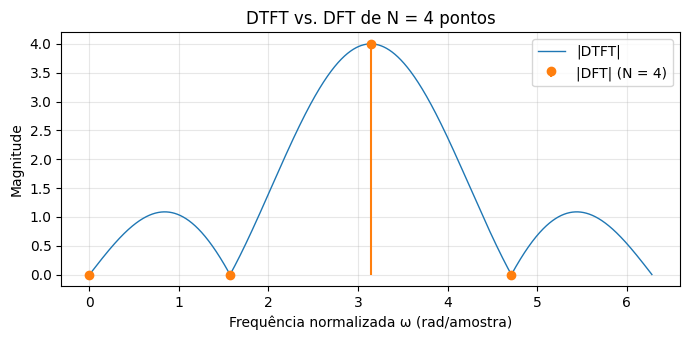

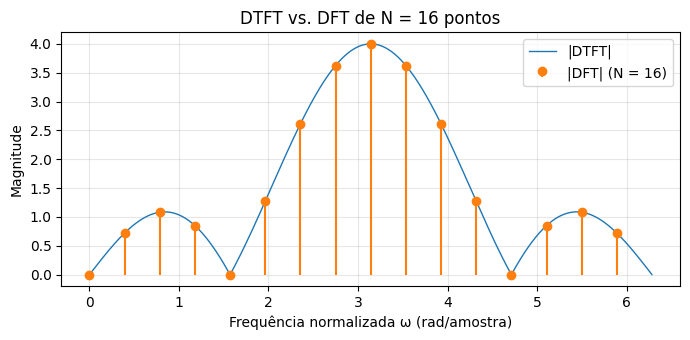

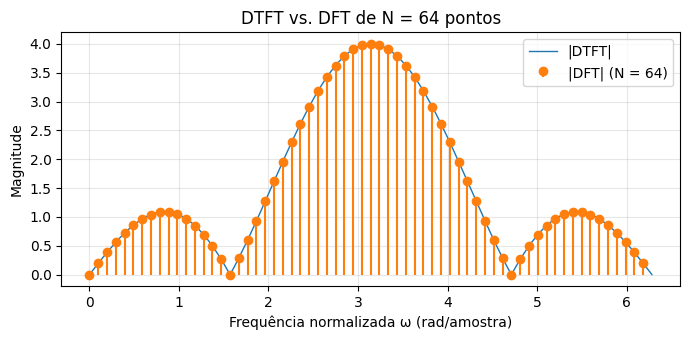

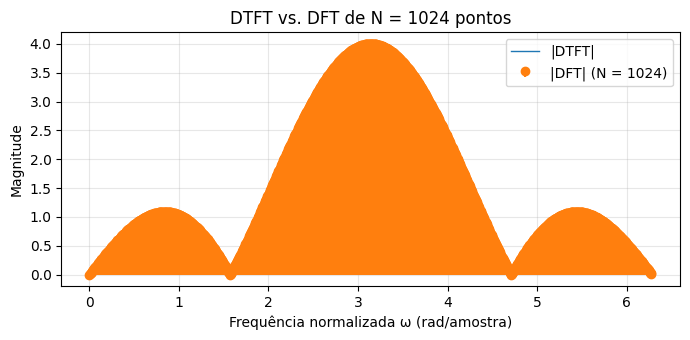

In [3]:
x_q1 = np.array([1.0, -1.0, 1.0, -1.0])

def calcular_dtft(x, n_pontos=4096):
    """DTFT avaliada em uma grade densa de frequências em [0, 2π)."""
    w = np.linspace(0, 2 * np.pi, n_pontos, endpoint=False)
    n = np.arange(len(x))
    X = np.exp(-1j * np.outer(w, n)) @ x
    return w, X


w_dtft, X_dtft = calcular_dtft(x_q1)

for N in [4, 16, 64, 1024]:
    X_dft = np.fft.fft(x_q1, n=N)
    w_dft = 2 * np.pi * np.arange(N) / N

    plt.figure(figsize=(7, 3.5))
    plt.plot(w_dtft, np.abs(X_dtft), linewidth=1.0, label="|DTFT|")
    plt.stem(w_dft, np.abs(X_dft), linefmt="C1-", markerfmt="C1o",
             basefmt=" ", label=f"|DFT| (N = {N})")
    plt.xlabel("Frequência normalizada ω (rad/amostra)")
    plt.ylabel("Magnitude")
    plt.title(f"DTFT vs. DFT de N = {N} pontos")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Questão 2 — Resolução espectral e zero-padding

x(t) = sin(2πt) + sin(2,2πt) → componentes em **f₁ = 1,0 Hz** e
**f₂ = 1,1 Hz** (separação de 0,1 Hz), amostrado a fs = 10 Hz.

A resolução espectral real é dada por Δf = fs/N_amostras = 1/T, onde T
é a **duração efetiva do sinal** — o zero-padding aumenta o número de
pontos da DFT (interpolando o espectro), mas **não** aumenta T e,
portanto, não melhora a resolução real.


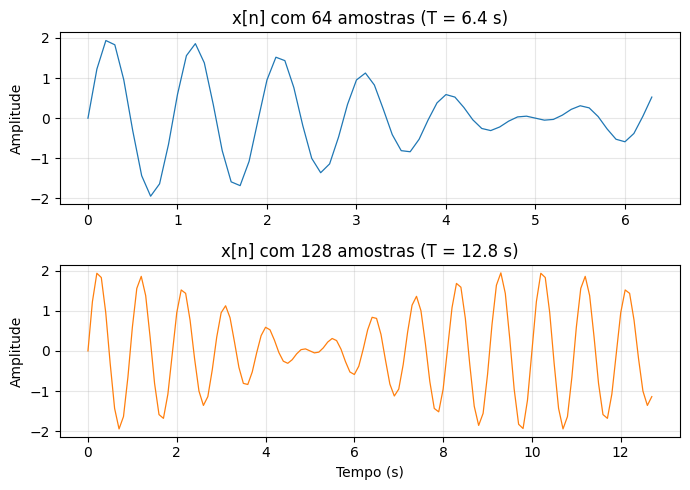

In [4]:
FS_Q2 = 10.0
F1, F2 = 1.0, 1.1

def gerar_sinal_q2(n_amostras, fs=FS_Q2):
    t = np.arange(n_amostras) / fs
    return t, np.sin(2 * np.pi * F1 * t) + np.sin(2 * np.pi * F2 * t)


t64, x64 = gerar_sinal_q2(64)
t128, x128 = gerar_sinal_q2(128)

fig, eixos = plt.subplots(2, 1, figsize=(7, 5), sharey=True)
eixos[0].plot(t64, x64, linewidth=0.9)
eixos[0].set_title(f"x[n] com 64 amostras (T = {64/FS_Q2:.1f} s)")
eixos[0].set_ylabel("Amplitude")
eixos[0].grid(True, alpha=0.3)
eixos[1].plot(t128, x128, linewidth=0.9, color="tab:orange")
eixos[1].set_title(f"x[n] com 128 amostras (T = {128/FS_Q2:.1f} s)")
eixos[1].set_xlabel("Tempo (s)")
eixos[1].set_ylabel("Amplitude")
eixos[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
def plotar_dft(x, n_dft, fs, titulo, xlim=(0, 2)):
    """Calcula e plota |DFT| de x com n_dft pontos (zero-padding se
    n_dft > len(x)), em função da frequência em Hz."""
    X = np.fft.rfft(x, n=n_dft)
    freqs = np.fft.rfftfreq(n_dft, d=1 / fs)
    mag = np.abs(X)

    plt.figure(figsize=(7, 3.5))
    plt.plot(freqs, mag, marker="o", markersize=3, linewidth=0.9)
    plt.axvline(F1, color="gray", linestyle="--", linewidth=0.8)
    plt.axvline(F2, color="gray", linestyle=":", linewidth=0.8)
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Magnitude")
    plt.title(titulo)
    plt.xlim(xlim)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return freqs, mag


print(f"Resolução com 64 amostras reais:  {FS_Q2/64:.4f} Hz")
print(f"Resolução com 128 amostras reais: {FS_Q2/128:.4f} Hz")
print(f"Separação entre as senoides:      {F2-F1:.4f} Hz")

Resolução com 64 amostras reais:  0.1562 Hz
Resolução com 128 amostras reais: 0.0781 Hz
Separação entre as senoides:      0.1000 Hz


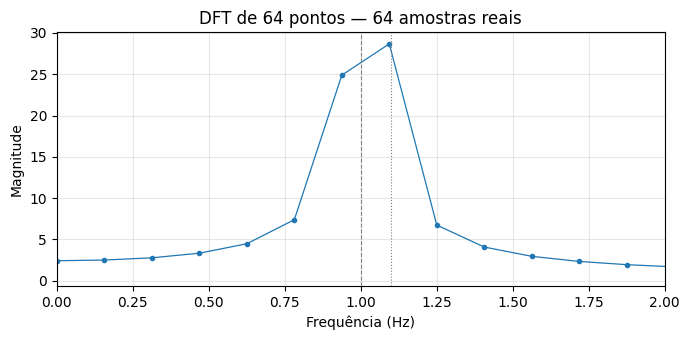

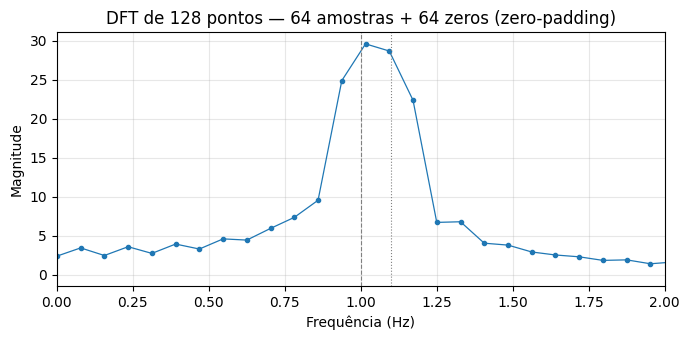

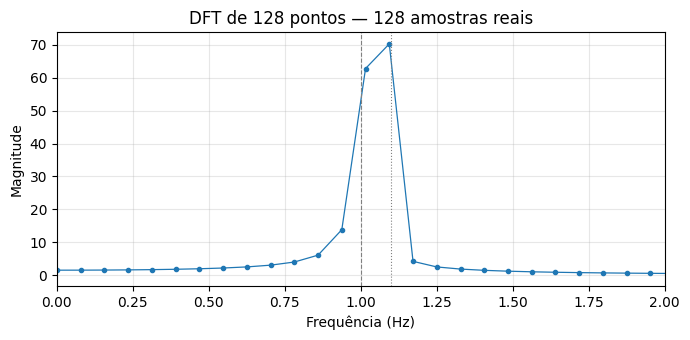

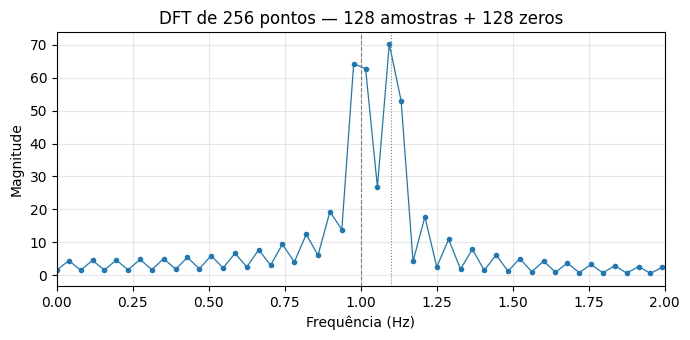

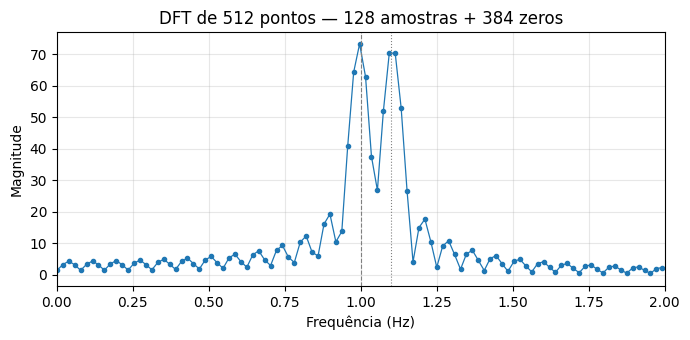

(array([0.        , 0.01953125, 0.0390625 , 0.05859375, 0.078125  ,
        0.09765625, 0.1171875 , 0.13671875, 0.15625   , 0.17578125,
        0.1953125 , 0.21484375, 0.234375  , 0.25390625, 0.2734375 ,
        0.29296875, 0.3125    , 0.33203125, 0.3515625 , 0.37109375,
        0.390625  , 0.41015625, 0.4296875 , 0.44921875, 0.46875   ,
        0.48828125, 0.5078125 , 0.52734375, 0.546875  , 0.56640625,
        0.5859375 , 0.60546875, 0.625     , 0.64453125, 0.6640625 ,
        0.68359375, 0.703125  , 0.72265625, 0.7421875 , 0.76171875,
        0.78125   , 0.80078125, 0.8203125 , 0.83984375, 0.859375  ,
        0.87890625, 0.8984375 , 0.91796875, 0.9375    , 0.95703125,
        0.9765625 , 0.99609375, 1.015625  , 1.03515625, 1.0546875 ,
        1.07421875, 1.09375   , 1.11328125, 1.1328125 , 1.15234375,
        1.171875  , 1.19140625, 1.2109375 , 1.23046875, 1.25      ,
        1.26953125, 1.2890625 , 1.30859375, 1.328125  , 1.34765625,
        1.3671875 , 1.38671875, 1.40625   , 1.42

In [6]:
# (i) 64 amostras reais, DFT de 64 pontos
plotar_dft(x64, 64, FS_Q2, "DFT de 64 pontos — 64 amostras reais")

# (ii) 64 amostras reais + 64 zeros -> DFT de 128 pontos (zero-padding)
plotar_dft(x64, 128, FS_Q2, "DFT de 128 pontos — 64 amostras + 64 zeros (zero-padding)")

# (iii) 128 amostras reais, DFT de 128 pontos
plotar_dft(x128, 128, FS_Q2, "DFT de 128 pontos — 128 amostras reais")

# (iv) 128 amostras reais + 128 zeros -> DFT de 256 pontos
plotar_dft(x128, 256, FS_Q2, "DFT de 256 pontos — 128 amostras + 128 zeros")

# (v) 128 amostras reais + 384 zeros -> DFT de 512 pontos
plotar_dft(x128, 512, FS_Q2, "DFT de 512 pontos — 128 amostras + 384 zeros")

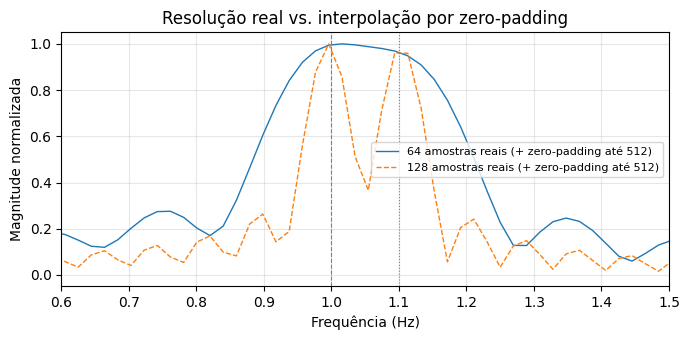

In [7]:
# Comparação direta: 64 amostras reais (com zero-padding) vs 128 amostras reais
X64_zp = np.abs(np.fft.rfft(x64, n=512))
f64_zp = np.fft.rfftfreq(512, d=1 / FS_Q2)
X128_zp = np.abs(np.fft.rfft(x128, n=512))
f128_zp = np.fft.rfftfreq(512, d=1 / FS_Q2)

plt.figure(figsize=(7, 3.5))
plt.plot(f64_zp, X64_zp / X64_zp.max(), linewidth=1.0,
         label="64 amostras reais (+ zero-padding até 512)")
plt.plot(f128_zp, X128_zp / X128_zp.max(), linewidth=1.0, linestyle="--",
         label="128 amostras reais (+ zero-padding até 512)")
plt.axvline(F1, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(F2, color="gray", linestyle=":", linewidth=0.8)
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude normalizada")
plt.title("Resolução real vs. interpolação por zero-padding")
plt.xlim(0.6, 1.5)
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Questão 3 — Compressão de sinais 1-D: DFT vs. DCT

Para cada fator de compressão de energia r, mantêm-se apenas os
coeficientes de maior magnitude que, somados, retêm a fração r da
energia total do sinal; os demais são zerados.

**Observação sobre a contagem de coeficientes:** a DCT de um sinal
real produz coeficientes reais (1 número real cada), enquanto a DFT
produz coeficientes complexos com simetria hermitiana — os bins
retidos vêm sempre em pares conjugados, cada par armazenando
1 número complexo = 2 números reais. Contando os bins da DFT como
feito abaixo (os dois membros de cada par), a contagem fica
diretamente comparável, em **números reais armazenados**, à da DCT.


handel.wav: fs = 8192 Hz, N = 73113 amostras


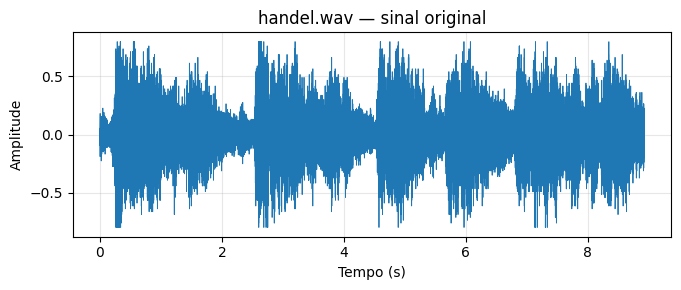

Sinal original:


In [8]:
fs_handel, x_handel = ler_wav("handel.wav")
print(f"handel.wav: fs = {fs_handel} Hz, N = {len(x_handel)} amostras")

plt.figure(figsize=(7, 3))
plt.plot(np.arange(len(x_handel)) / fs_handel, x_handel, linewidth=0.6)
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("handel.wav — sinal original")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Sinal original:")
tocar(x_handel, fs_handel)

In [9]:
def manter_maiores_por_energia(coeficientes, r):
    """Zera os menores coeficientes, mantendo os de maior magnitude que
    juntos retêm a fração r da energia total. Retorna os coeficientes
    comprimidos e a quantidade retida."""
    energia = np.abs(coeficientes) ** 2
    ordem = np.argsort(energia.ravel())[::-1]
    acumulada = np.cumsum(energia.ravel()[ordem])
    total = acumulada[-1]
    k = int(np.searchsorted(acumulada, r * total) + 1)

    comprimido = np.zeros_like(coeficientes)
    plano_c = comprimido.ravel()
    plano_o = coeficientes.ravel()
    plano_c[ordem[:k]] = plano_o[ordem[:k]]
    return plano_c.reshape(coeficientes.shape), k


def comprimir_dft(x, r):
    X = np.fft.fft(x)
    X_comp, k = manter_maiores_por_energia(X, r)
    return np.real(np.fft.ifft(X_comp)), k


def comprimir_dct(x, r):
    X = dct(x, norm="ortho")
    X_comp, k = manter_maiores_por_energia(X, r)
    return idct(X_comp, norm="ortho"), k


def erro_quadratico_medio(x, x_rec):
    return np.mean((x - x_rec) ** 2)

In [10]:
FATORES_R = [0.995, 0.99, 0.90, 0.75, 0.50]

resultados_q3 = {"DFT": {}, "DCT": {}}
sinais_comprimidos = {"DFT": {}, "DCT": {}}
N_handel = len(x_handel)

for r in FATORES_R:
    x_dft, k_dft = comprimir_dft(x_handel, r)
    x_dct, k_dct = comprimir_dct(x_handel, r)

    sinais_comprimidos["DFT"][r] = x_dft
    sinais_comprimidos["DCT"][r] = x_dct

    resultados_q3["DFT"][r] = (k_dft, k_dft / N_handel, erro_quadratico_medio(x_handel, x_dft))
    resultados_q3["DCT"][r] = (k_dct, k_dct / N_handel, erro_quadratico_medio(x_handel, x_dct))

    print(f"r = {r*100:5.1f}%  |  DFT: {k_dft:7d} coef. ({k_dft/N_handel*100:5.2f}%), MSE = {resultados_q3['DFT'][r][2]:.2e}"
          f"  |  DCT: {k_dct:7d} coef. ({k_dct/N_handel*100:5.2f}%), MSE = {resultados_q3['DCT'][r][2]:.2e}")

r =  99.5%  |  DFT:   48670 coef. (66.57%), MSE = 1.93e-04  |  DCT:   40702 coef. (55.67%), MSE = 1.93e-04
r =  99.0%  |  DFT:   40986 coef. (56.06%), MSE = 3.85e-04  |  DCT:   33683 coef. (46.07%), MSE = 3.85e-04
r =  90.0%  |  DFT:   11661 coef. (15.95%), MSE = 3.85e-03  |  DCT:    9038 coef. (12.36%), MSE = 3.85e-03
r =  75.0%  |  DFT:    4325 coef. ( 5.92%), MSE = 9.63e-03  |  DCT:    3200 coef. ( 4.38%), MSE = 9.63e-03
r =  50.0%  |  DFT:    1170 coef. ( 1.60%), MSE = 1.92e-02  |  DCT:     835 coef. ( 1.14%), MSE = 1.92e-02


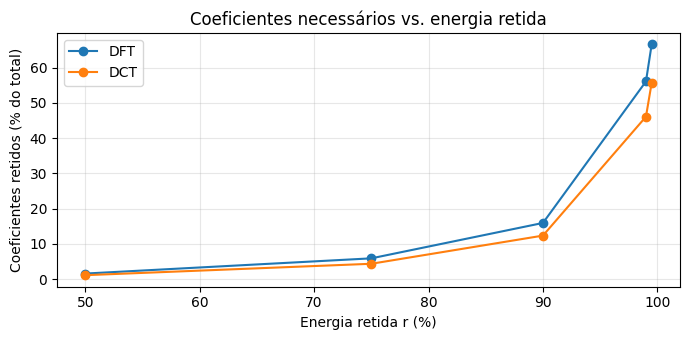

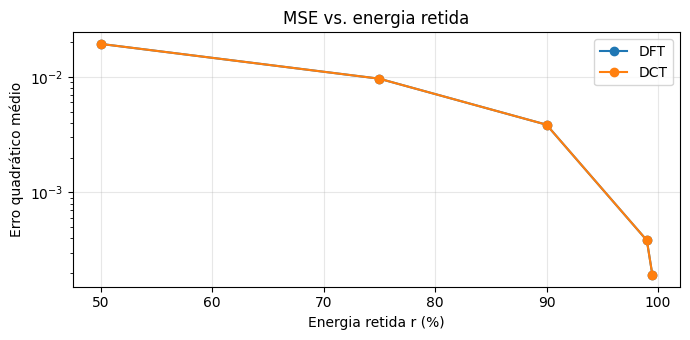

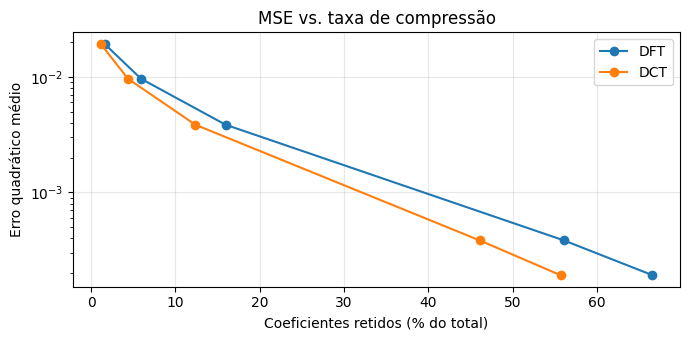

In [11]:
# Coeficientes retidos em função de r
plt.figure(figsize=(7, 3.5))
for transformada in ["DFT", "DCT"]:
    rs = [r * 100 for r in FATORES_R]
    coefs = [resultados_q3[transformada][r][1] * 100 for r in FATORES_R]
    plt.plot(rs, coefs, marker="o", label=transformada)
plt.xlabel("Energia retida r (%)")
plt.ylabel("Coeficientes retidos (% do total)")
plt.title("Coeficientes necessários vs. energia retida")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# MSE em função de r
plt.figure(figsize=(7, 3.5))
for transformada in ["DFT", "DCT"]:
    rs = [r * 100 for r in FATORES_R]
    mses = [resultados_q3[transformada][r][2] for r in FATORES_R]
    plt.plot(rs, mses, marker="o", label=transformada)
plt.xlabel("Energia retida r (%)")
plt.ylabel("Erro quadrático médio")
plt.yscale("log")
plt.title("MSE vs. energia retida")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# MSE em função da taxa de compressão
plt.figure(figsize=(7, 3.5))
for transformada in ["DFT", "DCT"]:
    taxas = [resultados_q3[transformada][r][1] * 100 for r in FATORES_R]
    mses = [resultados_q3[transformada][r][2] for r in FATORES_R]
    plt.plot(taxas, mses, marker="o", label=transformada)
plt.xlabel("Coeficientes retidos (% do total)")
plt.ylabel("Erro quadrático médio")
plt.yscale("log")
plt.title("MSE vs. taxa de compressão")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

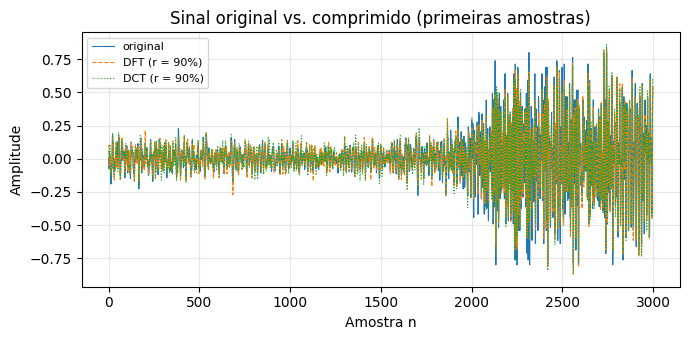

In [12]:
# Comparação no tempo — exemplo com r = 90%
r_exemplo = 0.90
n_janela = min(3000, N_handel)
plt.figure(figsize=(7, 3.5))
plt.plot(x_handel[:n_janela], linewidth=0.8, label="original")
plt.plot(sinais_comprimidos["DFT"][r_exemplo][:n_janela], linewidth=0.8,
         linestyle="--", label=f"DFT (r = {r_exemplo*100:.0f}%)")
plt.plot(sinais_comprimidos["DCT"][r_exemplo][:n_janela], linewidth=0.8,
         linestyle=":", label=f"DCT (r = {r_exemplo*100:.0f}%)")
plt.xlabel("Amostra n")
plt.ylabel("Amplitude")
plt.title("Sinal original vs. comprimido (primeiras amostras)")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Avaliação subjetiva: audição dos sinais comprimidos
for r in FATORES_R:
    print(f"--- r = {r*100:.1f}% ---")
    print("DFT:")
    tocar(sinais_comprimidos["DFT"][r], fs_handel)
    print("DCT:")
    tocar(sinais_comprimidos["DCT"][r], fs_handel)

--- r = 99.5% ---
DFT:


DCT:


--- r = 99.0% ---
DFT:


DCT:


--- r = 90.0% ---
DFT:


DCT:


--- r = 75.0% ---
DFT:


DCT:


--- r = 50.0% ---
DFT:


DCT:


## Questão 4 — Energia da imagem no domínio da DCT 2-D


sosias.jpg: 670 x 1200 pixels


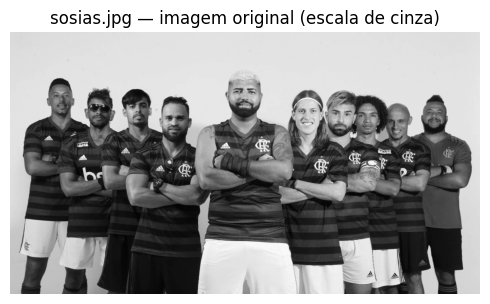

In [14]:
imagem = ler_imagem_cinza("sosias.jpg")
print(f"sosias.jpg: {imagem.shape[0]} x {imagem.shape[1]} pixels")

plt.figure(figsize=(5, 5))
plt.imshow(imagem, cmap="gray", vmin=0, vmax=255)
plt.title("sosias.jpg — imagem original (escala de cinza)")
plt.axis("off")
plt.tight_layout()
plt.show()

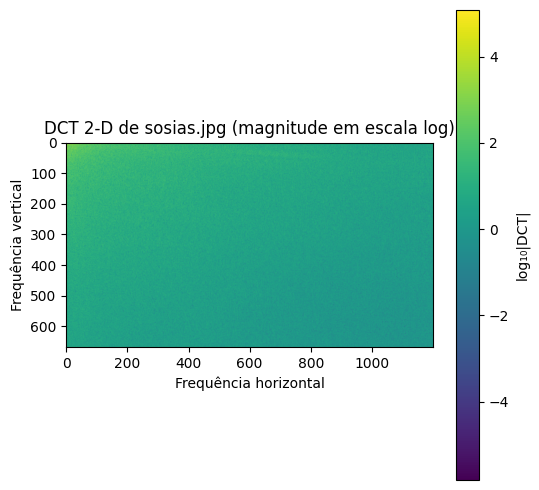

In [15]:
# DCT 2-D da imagem inteira
dct_imagem = dctn(imagem, norm="ortho")

plt.figure(figsize=(5.5, 5))
plt.imshow(np.log10(np.abs(dct_imagem) + 1e-6), cmap="viridis")
plt.colorbar(label="log₁₀|DCT|")
plt.title("DCT 2-D de sosias.jpg (magnitude em escala log)")
plt.xlabel("Frequência horizontal")
plt.ylabel("Frequência vertical")
plt.tight_layout()
plt.show()

90% da energia concentrada em 30 coeficientes (0.004% do total)
99% da energia concentrada em 5578 coeficientes (0.694% do total)


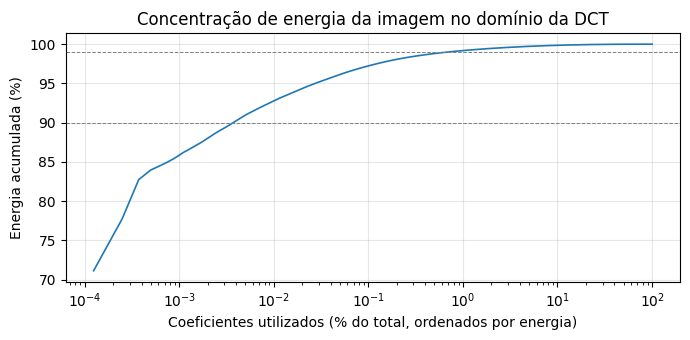

In [16]:
# Curva de energia acumulada: quantos coeficientes concentram a energia
energia = np.abs(dct_imagem.ravel()) ** 2
energia_ordenada = np.sort(energia)[::-1]
energia_acumulada = np.cumsum(energia_ordenada) / energia.sum()
fracao_coeficientes = np.arange(1, len(energia_acumulada) + 1) / len(energia_acumulada)

plt.figure(figsize=(7, 3.5))
plt.plot(fracao_coeficientes * 100, energia_acumulada * 100, linewidth=1.2)
for alvo in [0.90, 0.99]:
    k = int(np.searchsorted(energia_acumulada, alvo) + 1)
    plt.axhline(alvo * 100, color="gray", linestyle="--", linewidth=0.7)
    print(f"{alvo*100:.0f}% da energia concentrada em {k} coeficientes "
          f"({k/len(energia)*100:.3f}% do total)")
plt.xlabel("Coeficientes utilizados (% do total, ordenados por energia)")
plt.ylabel("Energia acumulada (%)")
plt.xscale("log")
plt.title("Concentração de energia da imagem no domínio da DCT")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Questão 5 — Compressão de imagem por DCT em blocos L×L

Para cada bloco L×L, aplica-se a DCT 2-D e mantêm-se os coeficientes
de maior magnitude que retêm a fração r da energia **daquele bloco**
(mesma lógica da Questão 3). L ∈ {8, 64} e r ∈ {95%, 50%}.


In [17]:
def comprimir_imagem_blocos(img, L, r):
    """Compressão por DCT em blocos L x L, retendo a fração r da energia
    de cada bloco. Retorna a imagem reconstruída e o total de
    coeficientes retidos."""
    altura, largura = img.shape
    # preenchimento para múltiplo de L (replicando as bordas)
    alt_pad = int(np.ceil(altura / L) * L)
    larg_pad = int(np.ceil(largura / L) * L)
    img_pad = np.pad(img, ((0, alt_pad - altura), (0, larg_pad - largura)), mode="edge")

    reconstruida = np.zeros_like(img_pad)
    total_coeficientes = 0

    for i in range(0, alt_pad, L):
        for j in range(0, larg_pad, L):
            bloco = img_pad[i:i + L, j:j + L]
            coef = dctn(bloco, norm="ortho")
            coef_comp, k = manter_maiores_por_energia(coef, r)
            reconstruida[i:i + L, j:j + L] = idctn(coef_comp, norm="ortho")
            total_coeficientes += k

    return reconstruida[:altura, :largura], total_coeficientes

In [18]:
VALORES_L = [8, 64]
FATORES_R_IMG = [0.95, 0.50]

n_pixels = imagem.size
resultados_q5 = {}

for L in VALORES_L:
    for r in FATORES_R_IMG:
        img_comp, k = comprimir_imagem_blocos(imagem, L, r)
        mse = np.mean((imagem - img_comp) ** 2)
        resultados_q5[(L, r)] = (img_comp, k, k / n_pixels, mse)
        print(f"L = {L:3d}, r = {r*100:4.1f}%  ->  {k:8d} coeficientes "
              f"({k/n_pixels*100:5.2f}% dos pixels), MSE = {mse:8.2f}")

L =   8, r = 95.0%  ->     20329 coeficientes ( 2.53% dos pixels), MSE =   128.76
L =   8, r = 50.0%  ->     12643 coeficientes ( 1.57% dos pixels), MSE =   410.18
L =  64, r = 95.0%  ->      3339 coeficientes ( 0.42% dos pixels), MSE =   584.05
L =  64, r = 50.0%  ->       218 coeficientes ( 0.03% dos pixels), MSE =  2369.53


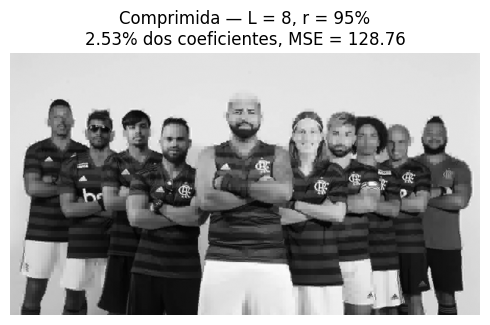

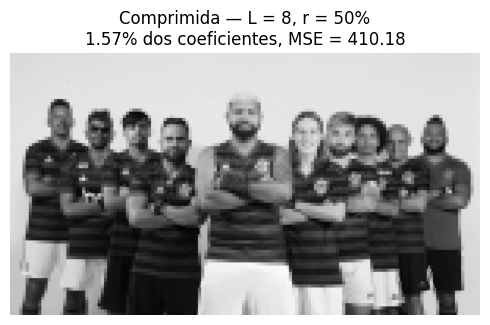

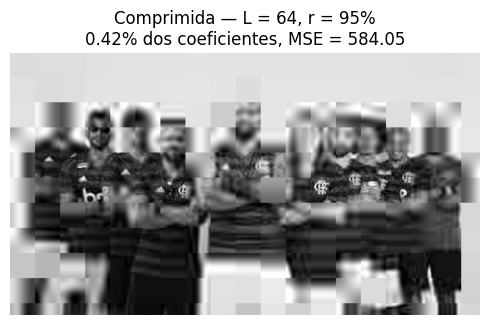

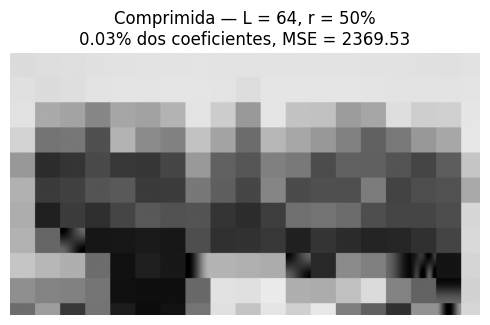

In [19]:
for (L, r), (img_comp, k, taxa, mse) in resultados_q5.items():
    plt.figure(figsize=(5, 5))
    plt.imshow(img_comp, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Comprimida — L = {L}, r = {r*100:.0f}%\n"
              f"{taxa*100:.2f}% dos coeficientes, MSE = {mse:.2f}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

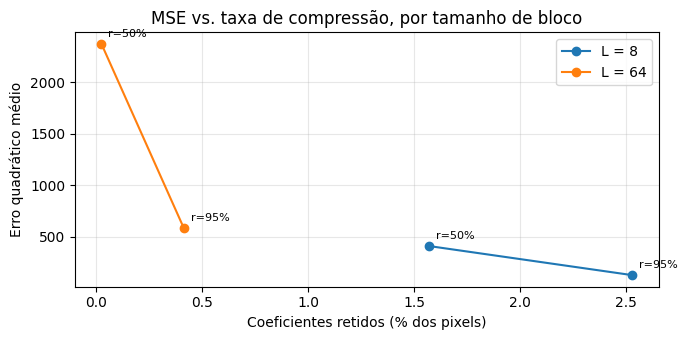

In [20]:
# MSE vs. taxa de compressão, por tamanho de bloco
plt.figure(figsize=(7, 3.5))
for L in VALORES_L:
    taxas = [resultados_q5[(L, r)][2] * 100 for r in FATORES_R_IMG]
    mses = [resultados_q5[(L, r)][3] for r in FATORES_R_IMG]
    plt.plot(taxas, mses, marker="o", label=f"L = {L}")
    for r, taxa, mse in zip(FATORES_R_IMG, taxas, mses):
        plt.annotate(f"r={r*100:.0f}%", (taxa, mse), textcoords="offset points",
                     xytext=(5, 5), fontsize=8)
plt.xlabel("Coeficientes retidos (% dos pixels)")
plt.ylabel("Erro quadrático médio")
plt.title("MSE vs. taxa de compressão, por tamanho de bloco")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()